#Fine-Tuning BERT for embeddings

## 1. Drive Connection  




In [ ]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/rcp-nlp

Mounted at /content/drive
/content/drive/MyDrive/rcp-nlp


## 2. Setup Environment  

In [ ]:
!pip install datasets
!pip install faiss-cpu
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.3/31.3 MB 58.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 2.4 MB/s eta 0:00:00


In [ ]:
import ast
import os
import re
import time
import random
import itertools
from collections import Counter

import numpy as np
import pandas as pd
import torch
import faiss
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import nltk
from nltk.corpus import stopwords

from datasets import Dataset, DatasetDict, load_from_disk
from transformers import AutoTokenizer
import evaluate

# ensure stopwords are available
nltk.download('stopwords', quiet=True)
stop_words = set(stopwords.words('english'))


In [ ]:
from transformers import (
    AutoTokenizer,
    AutoModelForMaskedLM,
    DataCollatorForLanguageModeling,
    TrainingArguments,
    Trainer,
)
from peft import PeftModel, PeftConfig, get_peft_model, LoraConfig
import torch.nn.functional as F

## 3. Data Loading  


In [ ]:
# Load tokenized dataset
from datasets import load_from_disk
tokenized_datasets = load_from_disk("file://./tokenized_recipes_dataset")

/usr/local/lib/python3.11/dist-packages/datasets/table.py:1421: FutureWarning: promote has been superseded by promote_options='default'.
  table = cls._concat_blocks(blocks, axis=0)


In [ ]:
from datasets import load_from_disk
ids_ds = load_from_disk("file://./recipe_input_ids_only")
print(ids_ds["train"][0])

{'input_ids': [101, 2516, 1024, 3707, 21569, 1005, 1055, 26375, 7975, 16521, 102, 12760, 1024, 1015, 5572, 13102, 7828, 5474, 1025, 1015, 5572, 13102, 7828, 2598, 2304, 11565, 1025, 1015, 5572, 13102, 7828, 12604, 8898, 20548, 1025, 1015, 7975, 1006, 1017, 1011, 6053, 1010, 5923, 1011, 1999, 3635, 1007, 1025, 4090, 2452, 26375, 12901, 1006, 2358, 1012, 3434, 2030, 5111, 2103, 2806, 1007, 1025, 1015, 5396, 2417, 20949, 1010, 3013, 2046, 1015, 1013, 1016, 4960, 4109, 1025, 1016, 7251, 24667, 3619, 20238, 9898, 1025, 1015, 7251, 24667, 2078, 2598, 13988, 2378, 1025, 4090, 2452, 14768, 6949, 1025, 2260, 2452, 14415, 9516, 5562, 1025, 2260, 9129, 25022, 5802, 13181, 1025, 1016, 8840, 21055, 2413, 7852, 1010, 3730, 1010, 3975, 1998, 3013, 2046, 1020, 1011, 4960, 4109, 102, 7826, 1024, 16130, 2362, 5474, 1010, 11565, 1998, 12604, 8898, 20548, 1012, 2275, 4998, 1015, 1013, 1016, 5572, 13102, 7828, 1012, 14548, 1996, 6893, 2046, 1996, 7975, 1005, 1055, 17790, 1998, 2006, 1996, 3096, 1012, 18651

In [ ]:
import torch

data = torch.load("./recipe_vocab_embeddings.pt")
token_ids = data["token_ids"]
tokens = data["tokens"]
embeddings = data["embeddings"]  # shape: [n_tokens, hidden_size]
print(f"Loaded {len(tokens)} unique dataset tokens.")

Loaded 22150 unique dataset tokens.


Installing and Importing Libraries

Converts each recipe’s title, ingredients list, and directions into a single text string, inserting [SEP] markers between sections. This unified field (df["text"]) is then ready for tokenisation and MLM fine-tuning.

## 4. Preprocessing & Persistence  


### 4.1 Make Text Column  

In [ ]:
def make_text_column(df):
    # Join ingredients and directions for each row
    df["text"] = (
        "TITLE: " + df["title"] +
        " [SEP] INGREDIENTS: " + df["ingredients"].apply(lambda x: " ; ".join(x)) +
        " [SEP] DIRECTIONS: " + df["directions"].apply(lambda x: " ".join(x))
    )
    return df

### 4.2 Filter & Save Recipes1M Subset

 - **Function `filter_and_save_recipes1m`**  
  1. **Load** full CSV with converters for `ingredients`, `directions`, and `ner` columns  
  2. **Filter** rows where `source == "Recipes1M"`  
  3. **Log** original vs. filtered row counts  
  4. **Compose** `text` column via `make_text_column()`  
  5. **Save** filtered DataFrame to new CSV


In [ ]:
import pandas as pd
import ast

def filter_and_save_recipes1m(input_path, output_path):
    converters = {
        'ingredients': ast.literal_eval,
        'directions': ast.literal_eval,
        'ner': ast.literal_eval
    }
    # Load the full dataset just this once
    df = pd.read_csv(input_path, converters=converters)
    # Filter for Recipes1M
    filtered_df = df[df['source'] == 'Recipes1M']
    print(f"Original size: {len(df)}, Filtered size: {len(filtered_df)}")
    filtered_df = make_text_column(filtered_df)
    # Save to new CSV
    filtered_df.to_csv(output_path, index=False)
    print(f"Filtered data saved to {output_path}")


full_data_path = '/content/drive/MyDrive/rcp-nlp/full_dataset.csv'
filtered_data_path = '/content/drive/MyDrive/rcp-nlp/recipes1m.csv'
filter_and_save_recipes1m(full_data_path, filtered_data_path)


Original size: 2231142, Filtered size: 588044
Filtered data saved to /content/drive/MyDrive/rcp-nlp/recipes1m_only.csv


- Start timer.  
- Read CSV at `filepath`, applying `ast.literal_eval` to `ingredients`, `directions` and `ner`; limit rows if `sample_size` is set.  
- Print number of recipes loaded and elapsed time.  
- Return the resulting DataFrame.  


## 5. Load Filtered Data  


### 5.1 Read Filtered CSV into DataFrame  


In [ ]:
def load_filtered_recipes(filepath, sample_size=None):
    """
    Load the filtered Recipes1M dataset from CSV

    Args:
        filepath: Path to the filtered_dataset.csv
        sample_size: Number of recipes to sample (None to load all)

    Returns:
        pandas DataFrame with the recipe data
    """
    start_time = time.time()

    # Define the converters to parse stringified lists
    converters = {
        'ingredients': ast.literal_eval,
        'directions': ast.literal_eval,
        'ner': ast.literal_eval
    }
    if sample_size is not None:
        df = pd.read_csv(filepath, converters=converters, nrows=sample_size)
    else:
        df = pd.read_csv(filepath, converters=converters)
    print(f"Loaded {len(df)} recipes from {filepath}")
    print(f"Data loaded in {time.time() - start_time:.2f} seconds")
    return df

# Usage:
filtered_data_path = '/content/drive/MyDrive/rcp-nlp/recipes1m.csv'
df = load_filtered_recipes(filtered_data_path)
df.rename(columns={'Unnamed: 0': 'id'}, inplace=True)

Loaded 588044 recipes from /content/drive/MyDrive/rcp-nlp/recipes1m_only.csv
Data loaded in 60.45 seconds


### 5.2 Read Filtered parquet format into DataFrame  


**Loading data via parquet file**
- for speeding up loading process

In [ ]:
import time
import pandas as pd

start_time = time.time()
df = pd.read_parquet('recipes1m.parquet')
df.rename(columns={'Unnamed: 0': 'id'}, inplace=True)
print(f"Loaded {len(df)} recipes from recipes1m_only.parquet")
print(f"Data loaded in {time.time() - start_time:.2f} seconds")

Loaded 588044 recipes from recipes1m_only.parquet
Data loaded in 29.88 seconds


In [ ]:
df.head()

,id,title,ingredients,directions,link,source,NER,text
0,1643098,Worlds Best Mac and Cheese,"[6 ounces penne, 2 cups Beechers Flagship Chee...",[Preheat the oven to 350 F. Butter or oil an 8...,www.epicurious.com/recipes/food/views/-world-s...,Recipes1M,"[""penne"", ""Beechers Flagship Cheese Sauce"", ""C...",TITLE: Worlds Best Mac and Cheese [SEP] INGRED...
1,1643099,Dilly Macaroni Salad Recipe,"[1 c. elbow macaroni, 1 c. cubed American chee...",[Cook macaroni according to package directions...,cookeatshare.com/recipes/dilly-macaroni-salad-...,Recipes1M,"[""elbow macaroni"", ""American cheese"", ""celery""...",TITLE: Dilly Macaroni Salad Recipe [SEP] INGRE...
2,1643100,Gazpacho,"[8 tomatoes, quartered, Kosher salt, 1 red oni...",[Add the tomatoes to a food processor with a p...,www.foodnetwork.com/recipes/gazpacho1.html,Recipes1M,"[""tomatoes"", ""Kosher salt"", ""red onion"", ""gree...","TITLE: Gazpacho [SEP] INGREDIENTS: 8 tomatoes,..."
3,1643101,Kombu Tea Grilled Chicken Thigh,"[2 Chicken thighs, 2 tsp Kombu tea, 1 White pe...",[Pierce the skin of the chicken with a fork or...,cookpad.com/us/recipes/150100-kombu-tea-grille...,Recipes1M,"[""Chicken"", ""White pepper""]",TITLE: Kombu Tea Grilled Chicken Thigh [SEP] I...
4,1643102,Zucchini Nut Bread,"[2 cups flour, 1 tablespoon cinnamon, 2 teaspo...","[Sift dry ingredients., beat eggs untill froth...",www.food.com/recipe/zucchini-nut-bread-329682,Recipes1M,"[""flour"", ""cinnamon"", ""baking soda"", ""salt"", ""...",TITLE: Zucchini Nut Bread [SEP] INGREDIENTS: 2...


**Construct HF `DatasetDict` & Splits**

- Convert `df` to a Hugging Face `Dataset` and clear `df` to free memory.  
- Wrap in a `DatasetDict` with key `"train"`.  
- Split `"train"` into 80/20 train/rest, then split `rest` 50/50 into `"validation"` and `"test"` (seed=42 for reproducibility).  
- Rename keys to `"train"`, `"validation"`, `"test"`.  
- Print the `DatasetDict` and counts per split.  
- Show a sample record from the training set.  


In [ ]:
from datasets import Dataset, DatasetDict

# 1. Convert pandas DataFrame to a Hugging Face Dataset
train_ds = Dataset.from_pandas(df, preserve_index=False)
df = []  # free up memory

# 2. Build a DatasetDict with a single 'train' split
dataset = DatasetDict({"train": train_ds})

# 3. Split into train, validation, and test
split_train_rest = dataset["train"].train_test_split(test_size=0.2, seed=42)
split_valid_test = split_train_rest["test"].train_test_split(test_size=0.5, seed=42)

# 4. Rename the splits appropriately
dataset = DatasetDict({
    "train": split_train_rest["train"],
    "validation": split_valid_test["train"],
    "test": split_valid_test["test"],
})

# 5. Print summary info
print(dataset)
print(f"  • train examples:      {len(dataset['train'])}")
print(f"  • validation examples: {len(dataset['validation'])}")
print(f"  • test examples: {len(dataset['test'])}")

# 6. Example: access a single item
print(dataset["train"][1])

DatasetDict({
    train: Dataset({
        features: ['id', 'title', 'ingredients', 'directions', 'link', 'source', 'NER', 'text'],
        num_rows: 470435
    })
    validation: Dataset({
        features: ['id', 'title', 'ingredients', 'directions', 'link', 'source', 'NER', 'text'],
        num_rows: 58804
    })
    test: Dataset({
        features: ['id', 'title', 'ingredients', 'directions', 'link', 'source', 'NER', 'text'],
        num_rows: 58805
    })
})
  • train examples:      470435
  • validation examples: 58804
  • test examples: 58805
{'id': 2019561, 'title': 'Simmered Maitake and Atsuage', 'ingredients': ['1 pack Maitake mushrooms', '2 blocks Atsuage', '300 ml Dashi stock', '1 tbsp Usukuchi soy sauce', '1/2 tbsp Sugar', '1 Mitsuba'], 'directions': ['Remove the stump from the maitake mushrooms and shred into small clumps.', 'Cut the atsuage into bite-sized pieces.', 'Cut the mitsuba into 2-3 cm strips (I set aside some whole mitsuba leaves for garnish).', 'Combine the d

In [ ]:
# inspect
print(dataset["train"][1]["text"])

TITLE: Simmered Maitake and Atsuage [SEP] INGREDIENTS: 1 pack Maitake mushrooms ; 2 blocks Atsuage ; 300 ml Dashi stock ; 1 tbsp Usukuchi soy sauce ; 1/2 tbsp Sugar ; 1 Mitsuba [SEP] DIRECTIONS: Remove the stump from the maitake mushrooms and shred into small clumps. Cut the atsuage into bite-sized pieces. Cut the mitsuba into 2-3 cm strips (I set aside some whole mitsuba leaves for garnish). Combine the dashi stock, sugar, and soy sauce in a pot and turn on the heat. Once it comes to a boil, add the atsuage and maitake mushrooms and simmer on medium heat for 6-7 minutes. Finally, add the chopped mitsuba, bring back to a boil, and it's done. After transferring to the bowls, you could top with some leaves to garnish.


## 6. Training Configuration  


**Get latest checkpoint**

- Verify `checkpoint_dir` exists; return `None` if missing.  *italicized text*
- Return its full path or `None` when no checkpoints are found.  


In [ ]:
import os
import re

def get_latest_checkpoint(checkpoint_dir):
    if not os.path.exists(checkpoint_dir):
        return None
    subdirs = [d for d in os.listdir(checkpoint_dir) if os.path.isdir(os.path.join(checkpoint_dir, d))]
    checkpoint_pattern = re.compile(r"checkpoint-(\d+)")
    checkpoints = []
    for subdir in subdirs:
        match = checkpoint_pattern.match(subdir)
        if match:
            checkpoints.append((int(match.group(1)), subdir))
    if not checkpoints:
        return None
    latest_checkpoint = max(checkpoints)[1]
    return os.path.join(checkpoint_dir, latest_checkpoint)

### 6.1 Tokenization  


#### 6.1.1 Load Tokenizer (Checkpoint Fallback)  


**Load Tokenizer with Checkpoint Fallback**

- Scan `checkpoint_dir` for subfolders named `checkpoint-<step>` and pick the highest step via `get_latest_checkpoint()`.  
- Define `checkpoint_dir = "./distilbert-mlm-lora-checkpoints"` and `base_model_name = "distilbert-base-uncased"`.  
- If a checkpoint is found, print its path and load the tokenizer from there; otherwise print a fallback message and load the base tokenizer.  


In [ ]:
checkpoint_dir = "./distilbert-mlm-lora-checkpoints"
base_model_name = "distilbert-base-uncased"

latest_ckpt_path = get_latest_checkpoint(checkpoint_dir)
if latest_ckpt_path is not None:
    print(f"Loading tokenizer from latest checkpoint: {latest_ckpt_path}")
    tokenizer = AutoTokenizer.from_pretrained(latest_ckpt_path)
else:
    print(f"No checkpoint found in {checkpoint_dir}. Loading base tokenizer: {base_model_name}")
    tokenizer = AutoTokenizer.from_pretrained(base_model_name)


Loading tokenizer from latest checkpoint: ./distilbert-mlm-lora-checkpoints/checkpoint-93000


#### 6.1.2 Apply Truncation & Padding  


**Tokenization & Truncation**

- Define `tokenize_truncate(examples)` to run `tokenizer` on `examples["text"]` with `truncation=True`, `padding="max_length"`, and `max_length=512`.  
- Apply it across all splits using `dataset.map(..., batched=True)`.  
- Print the resulting `tokenized_datasets` overview and the first 20 `input_ids` from the training split.  


In [ ]:
# 3. Define a simple tokenize function
def tokenize_truncate(examples):
    # This will:
    #  - truncate any sequence longer than max_length
    #  - pad any sequence shorter than max_length
    return tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=512,          # choose up to 512 if you have the memory
    )

# 4. Apply it to every split
tokenized_datasets = dataset.map(
    tokenize_truncate,
    batched=True,
)

print(tokenized_datasets)
print("Example of tokenized input IDs:", tokenized_datasets["train"][0]["input_ids"][:20])


Map:   0%|          | 0/470435 [00:00<?, ? examples/s]

Map:   0%|          | 0/58804 [00:00<?, ? examples/s]

Map:   0%|          | 0/58805 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'title', 'ingredients', 'directions', 'link', 'source', 'NER', 'text', 'input_ids', 'attention_mask'],
        num_rows: 470435
    })
    validation: Dataset({
        features: ['id', 'title', 'ingredients', 'directions', 'link', 'source', 'NER', 'text', 'input_ids', 'attention_mask'],
        num_rows: 58804
    })
    test: Dataset({
        features: ['id', 'title', 'ingredients', 'directions', 'link', 'source', 'NER', 'text', 'input_ids', 'attention_mask'],
        num_rows: 58805
    })
})
Example of tokenized input IDs: [101, 2516, 1024, 3707, 21569, 1005, 1055, 26375, 7975, 16521, 102, 12760, 1024, 1015, 5572, 13102, 7828, 5474, 1025, 1015]


**Save Tokenized Datasets**

- Persist the `tokenized_datasets` object to `"./tokenized_recipes_dataset"` on disk.  
- Allows fast reload later via `datasets.load_from_disk` without re-running tokenization.  


In [ ]:
tokenized_datasets.save_to_disk("./tokenized_recipes_dataset")

Saving the dataset (0/5 shards):   0%|          | 0/470435 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/58804 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/58805 [00:00<?, ? examples/s]

**Extract & Save `input_ids` Only**

- Create `input_ids_only` by removing all columns except `"input_ids"` from each split.  
- Print `input_ids_only` overview and first record to verify.  
- Save the stripped-down datasets to `"recipe_input_ids_only"` on disk (Arrow format).  


In [ ]:
from datasets import DatasetDict

# 1.  Strip every split down to just the input_ids column
input_ids_only = DatasetDict({
    split_name: split_ds.remove_columns(
        [col for col in split_ds.column_names if col != "input_ids"]
    )
    for split_name, split_ds in tokenized_datasets.items()
})

# 2.  (Optional) check the result
print(input_ids_only)
print(input_ids_only["train"][0])        # should show only {'input_ids': [...]}

# 3.  Persist to disk (Arrow format; efficient & memory-mapped)
input_ids_only.save_to_disk("recipe_input_ids_only")

DatasetDict({
    train: Dataset({
        features: ['input_ids'],
        num_rows: 470435
    })
    validation: Dataset({
        features: ['input_ids'],
        num_rows: 58804
    })
    test: Dataset({
        features: ['input_ids'],
        num_rows: 58805
    })
})
{'input_ids': [101, 2516, 1024, 3707, 21569, 1005, 1055, 26375, 7975, 16521, 102, 12760, 1024, 1015, 5572, 13102, 7828, 5474, 1025, 1015, 5572, 13102, 7828, 2598, 2304, 11565, 1025, 1015, 5572, 13102, 7828, 12604, 8898, 20548, 1025, 1015, 7975, 1006, 1017, 1011, 6053, 1010, 5923, 1011, 1999, 3635, 1007, 1025, 4090, 2452, 26375, 12901, 1006, 2358, 1012, 3434, 2030, 5111, 2103, 2806, 1007, 1025, 1015, 5396, 2417, 20949, 1010, 3013, 2046, 1015, 1013, 1016, 4960, 4109, 1025, 1016, 7251, 24667, 3619, 20238, 9898, 1025, 1015, 7251, 24667, 2078, 2598, 13988, 2378, 1025, 4090, 2452, 14768, 6949, 1025, 2260, 2452, 14415, 9516, 5562, 1025, 2260, 9129, 25022, 5802, 13181, 1025, 1016, 8840, 21055, 2413, 7852, 1010, 3730, 1010

Saving the dataset (0/2 shards):   0%|          | 0/470435 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/58804 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/58805 [00:00<?, ? examples/s]

In [ ]:
print(tokenized_datasets)
print("Example of tokenized input IDs:", tokenized_datasets["train"][0]["input_ids"][:20])

DatasetDict({
    train: Dataset({
        features: ['id', 'title', 'ingredients', 'directions', 'link', 'source', 'NER', 'text', 'input_ids', 'attention_mask'],
        num_rows: 470435
    })
    validation: Dataset({
        features: ['id', 'title', 'ingredients', 'directions', 'link', 'source', 'NER', 'text', 'input_ids', 'attention_mask'],
        num_rows: 58804
    })
    test: Dataset({
        features: ['id', 'title', 'ingredients', 'directions', 'link', 'source', 'NER', 'text', 'input_ids', 'attention_mask'],
        num_rows: 58805
    })
})
Example of tokenized input IDs: [101, 2516, 1024, 3707, 21569, 1005, 1055, 26375, 7975, 16521, 102, 12760, 1024, 1015, 5572, 13102, 7828, 5474, 1025, 1015]


### 6.2 Data Collator  


**Data Collator Setup**

- Instantiate `data_collator` with:
  - `tokenizer`
  - `mlm=True` (enable masked LM)
  - `mlm_probability=0.15` (mask 15% of tokens)  


In [ ]:
from transformers import DataCollatorForLanguageModeling

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=True,
    mlm_probability=0.15,
)

### 6.3 Model & PEFT Setup  


**Setup & PEFT Model Initialization**

- Define paths and LoRA config: `checkpoint_dir`, `base_model_name`, `lora_kwargs`.  
- Find latest checkpoint via `get_latest_checkpoint(checkpoint_dir)`.  
- Load `tokenizer` from checkpoint if available, else from the base model.  
- Load base MLM model.
- Create `LoraConfig(**lora_kwargs)` and wrap the base model with `get_peft_model`.  
- Activate adapter layers and print trainable vs. total parameters.  


In [ ]:
# === SET YOUR DIRS AND CONFIG HERE ===
checkpoint_dir = "./distilbert-mlm-lora-checkpoints"
base_model_name = "distilbert-base-uncased"
lora_kwargs = dict(
    task_type="CAUSAL_LM",
    r=8,
    lora_alpha=32,
    lora_dropout=0.01,
    target_modules=['q_lin'],
)

# === LOAD TOKENIZER (ALWAYS NEEDED) ===
latest_ckpt_path = get_latest_checkpoint(checkpoint_dir)
if latest_ckpt_path is not None:
    print(f"Checkpoint found: {latest_ckpt_path}")
    tokenizer = AutoTokenizer.from_pretrained(latest_ckpt_path)
else:
    print("No checkpoint found, using base model tokenizer.")
    tokenizer = AutoTokenizer.from_pretrained(base_model_name)

# === LOAD OR INIT MODEL ===
# if latest_ckpt_path is not None:
#     # 1. Load base model
#     base_model = AutoModelForMaskedLM.from_pretrained(base_model_name)
#     # 2. Attach PEFT (LoRA) adapter weights from checkpoint
#     model = PeftModel.from_pretrained(base_model, latest_ckpt_path)
#     print("Loaded PEFT model from checkpoint.")
# else:
# 1. Load base model
base_model = AutoModelForMaskedLM.from_pretrained(base_model_name)
# 2. Setup new PEFT config and model
peft_config = LoraConfig(**lora_kwargs)
model = get_peft_model(base_model, peft_config)
print("Initialized new PEFT model.")

# (Optional) Print trainable parameters for confirmation
model.enable_adapter_layers()
model.print_trainable_parameters()

Checkpoint found: ./distilbert-mlm-lora-checkpoints/checkpoint-93000


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Initialized new PEFT model.
trainable params: 73,728 || all params: 67,059,258 || trainable%: 0.1099


In [ ]:
# hyperparameters
lr = 1e-3
batch_size = 16
num_epochs = 5

**Evaluation Metric Setup**

- Load the `"accuracy"` metric.
  


In [ ]:
import evaluate
import torch
import numpy as np

# import accuracy evaluation metric
accuracy = evaluate.load("accuracy")

# define an evaluation function to pass into trainer later
def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=1)

    return {"accuracy": accuracy.compute(predictions=predictions, references=labels)}


**TrainingArguments**

- Configure checkpointing and logging:
- Set training hyperparameters:


### 6.4 TrainingArguments  


In [ ]:
# 5. Training arguments
training_args = TrainingArguments(
    output_dir="distilbert-mlm-lora-checkpoints",
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    num_train_epochs=num_epochs,
    learning_rate=lr,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",         # or "steps"
    save_total_limit=1,            # only keep last 1 checkpoint
    load_best_model_at_end=True,
    report_to="none",
    logging_strategy="epoch",
    fp16=True,
    # resume_from_checkpoint=latest_ckpt_path
)

**Trainer & Training**

- Instantiate the `Trainer`
- Start training
- Save just the LoRA adapters


### 6.5 Trainer & Training Phase  


In [ ]:
# 6. Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    tokenizer=tokenizer
)

# 7. Train
trainer.train(resume_from_checkpoint=latest_ckpt_path)

# 8. (Optional) save just the LoRA adapters
model.save_pretrained("distilbert-mlm-lora-adapters")

<ipython-input-22-904a62fbf3ff>:2: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


In [ ]:
# 9. Save the tokenizer separately (always good practice)
tokenizer.save_pretrained("./bert-recipe-mlm-lora-adapters")

## 7. Embeddings  


### 7.1 Token Embeddings  


#### 7.1.1 Save Raw BERT Embedding Matrix  


**Extract & Save Embedding Matrix**

- Retrieve input-embedding weights via `model.get_input_embeddings().weight`.  
- Detach from GPU and move to CPU.  
- Save tensor to `./bert_embeddings.pt` with `torch.save`.  


In [ ]:
# 10. Extract and save the input-embedding matrix (for feature use, analysis, or transfer)
# If using PEFT, the model's get_input_embeddings() is still available
emb_weights = model.get_input_embeddings().weight.detach().cpu()
torch.save(emb_weights, "./bert_embeddings.pt")

**Load Embeddings & Tokenizer**

- Load the saved embedding tensor from `./bert_embeddings.pt` into `emb`.   
- Load the `tokenizer` from that checkpoint if available, otherwise fall back to `base_model_name`.  
- Print out the shape of the embedding matrix (e.g., `(30522, 768)`).  


In [ ]:
# Load the embeddings (and your trained tokenizer)
emb = torch.load("./bert_embeddings.pt")

# === SET YOUR DIRS AND CONFIG HERE ===
checkpoint_dir = "./distilbert-mlm-lora-checkpoints"
# === LOAD TOKENIZER (ALWAYS NEEDED) ===
latest_ckpt_path = get_latest_checkpoint(checkpoint_dir)
if latest_ckpt_path is not None:
    print(f"Checkpoint found: {latest_ckpt_path}")
    tokenizer = AutoTokenizer.from_pretrained(latest_ckpt_path)
else:
    print("No checkpoint found, using base model tokenizer.")
    tokenizer = AutoTokenizer.from_pretrained(base_model_name)

print("Embedding matrix shape:", emb.shape)  # e.g., (30522, 768)


Checkpoint found: ./distilbert-mlm-lora-checkpoints/checkpoint-93000
Embedding matrix shape: torch.Size([30522, 768])


**Embedding Similarity & PCA Visualization**

- Retrieve top-N semantically related tokens via cosine similarity on the fine-tuned input embeddings.  
- Apply PCA to project high-dimensional embeddings into 2D, enabling visual inspection of semantic clusters (e.g., ingredient groupings).  


**Semantic Embedding Exploration**

Leverage the fine-tuned embedding space to:

- **Find similar tokens** using cosine similarity:  
  $$
    \text{cosine_sim}(u, v) \;=\; \frac{\displaystyle\sum_i u_i \, v_i}{\sqrt{\displaystyle\sum_i u_i^2}\;\sqrt{\displaystyle\sum_i v_i^2}}
  $$

In [ ]:
import torch.nn.functional as F

def most_similar(word, emb, tokenizer, topn=50):
    idx = tokenizer.convert_tokens_to_ids(word)
    query_vec = emb[idx].unsqueeze(0)
    sims = F.cosine_similarity(query_vec, emb)
    topk = torch.topk(sims, topn + 1)  # +1 to skip the word itself
    shown = 0
    for i, sim in zip(topk.indices, topk.values):
        token = tokenizer.convert_ids_to_tokens(int(i))
        if token == word: continue
        print(f"{shown+1}: {token} (id={int(i)})  similarity={sim:.3f}")
        shown += 1
        if shown >= topn: break


most_similar("pasta", emb, tokenizer)


1: spaghetti (id=26666)  similarity=0.768
2: noodles (id=27130)  similarity=0.766
3: 1736 (id=28192)  similarity=0.743
4: seafood (id=23621)  similarity=0.743
5: 1754 (id=22593)  similarity=0.742
6: 1759 (id=21667)  similarity=0.742
7: 36th (id=21460)  similarity=0.741
8: 1718 (id=26995)  similarity=0.740
9: 1732 (id=27582)  similarity=0.739
10: 1721 (id=27689)  similarity=0.739
11: sausage (id=24165)  similarity=0.739
12: 37th (id=23027)  similarity=0.738
13: 1756 (id=22370)  similarity=0.738
14: 1761 (id=21364)  similarity=0.738
15: 1757 (id=22621)  similarity=0.738
16: 1762 (id=20827)  similarity=0.737
17: 1634 (id=28502)  similarity=0.737
18: ط (id=1286)  similarity=0.737
19: 1717 (id=27525)  similarity=0.736
20: 1779 (id=17616)  similarity=0.736
21: 32nd (id=20628)  similarity=0.736
22: steak (id=21475)  similarity=0.736
23: 1728 (id=26833)  similarity=0.736
24: 1638 (id=27497)  similarity=0.736
25: 1641 (id=25702)  similarity=0.736
26: 1704 (id=27769)  similarity=0.736
27: 1727 (

**Note on Raw BERT Embedding Neighbors**

Because we’re querying against the full BERT vocabulary—even tokens never seen in our recipe corpus—the top-ranked “similar” embeddings include many numeric subwords and out-of-domain tokens. For example, querying `"pasta"` yields:

```plaintext
1. spaghetti (id=26666)  similarity=0.768  
2. noodles   (id=27130)  similarity=0.766  
3. 1736      (id=28192)  similarity=0.743  
4. seafood   (id


**Filtered Semantic Neighbors**

After computing raw cosine similarities against the full BERT vocab, we refine the results by:

- **Alphabetic filter**: Keep only tokens matching `^[a-zA-Z]+$` (no numbers or punctuation).  
- **Subword & special token exclusion**: Discard tokens starting with `##` or `[` to avoid fragments and reserved tokens.  
- **Top-N display**: Print the highest-scoring full words (e.g., “spaghetti”, “noodles”) for clearer culinary insights.  


In [ ]:
import re

def is_good_token(token):
    return (
        bool(re.match(r"^[a-zA-Z]+$", token))  # only alphabetic words
        and not token.startswith("##")         # not a subword
        and not token.startswith("[")          # not special token
    )

def most_similar_words_only(word, emb, tokenizer, topn=10):
    idx = tokenizer.convert_tokens_to_ids(word)
    query_vec = emb[idx].unsqueeze(0)
    sims = F.cosine_similarity(query_vec, emb)
    sorted_indices = torch.argsort(sims, descending=True)
    count = 0
    for i in sorted_indices:
        token = tokenizer.convert_ids_to_tokens(int(i))
        if token == word: continue
        if is_good_token(token):
            print(f"{count+1}: {token:15} similarity={sims[i]:.3f}")
            count += 1
            if count >= topn:
                break

most_similar_words_only("pasta", emb, tokenizer)


1: spaghetti       similarity=0.768
2: noodles         similarity=0.766
3: seafood         similarity=0.743
4: sausage         similarity=0.739
5: steak           similarity=0.736
6: ferocious       similarity=0.733
7: salsa           similarity=0.733
8: tormented       similarity=0.731
9: tuscany         similarity=0.731
10: tomato          similarity=0.730


#### 7.1.2 Extract Dataset-Specific Embeddings  


**Filtering Embeddings to Dataset Vocabulary**
**Build dataset vocabulary**
- Extract all unique tokens/words from dataset.
If recipes are already tokenized (using tokenizer), just collect all unique token IDs.

In [ ]:
# `tokenized_datasets` is a DatasetDict with splits like
#   "train", "validation", "test", ...
all_token_ids = set()

for split_name, split_ds in tokenized_datasets.items():
    print(f"Scanning “{split_name}” ({len(split_ds):,} examples)…")
    for example in tqdm(split_ds, leave=False):
        all_token_ids.update(example["input_ids"])

print(f"\nTotal unique tokens across ALL splits: {len(all_token_ids):,}")


Scanning “train” (470,435 examples)…


  0%|          | 0/470435 [00:00<?, ?it/s]

KeyboardInterrupt: 

**Extract those rows from the embedding matrix**

In [ ]:
import torch

# Load your trained embedding matrix (already done)
emb = torch.load("./bert_embeddings.pt")  # shape: [vocab_size, hidden_size]

# Turn your set of token IDs into a sorted list (for reproducibility)
dataset_token_ids = sorted(list(all_token_ids))
dataset_embeddings = emb[dataset_token_ids]  # shape: [n_tokens_in_dataset, hidden_size]

**Get corresponding token strings**

In [ ]:
dataset_tokens = [tokenizer.convert_ids_to_tokens(i) for i in dataset_token_ids]

**Map token string → embedding for easy lookup**

In [ ]:
token2vec = {token: vec for token, vec in zip(dataset_tokens, dataset_embeddings)}

**Save or analyze**

In [ ]:
# Save the filtered embeddings
torch.save({
    "token_ids": dataset_token_ids,
    "tokens": dataset_tokens,
    "embeddings": dataset_embeddings
}, "./recipe_vocab_embeddings.pt")

# Now, your embeddings file contains only relevant vectors!

**Load embeddings**

In [ ]:
import torch

data = torch.load("./recipe_vocab_embeddings.pt")
token_ids = data["token_ids"]
tokens = data["tokens"]
embeddings = data["embeddings"]  # shape: [n_tokens, hidden_size]
print(f"Loaded {len(tokens)} unique dataset tokens.")


Loaded 22150 unique dataset tokens.


#### 7.1.3 Similarity Analysis  


##### 7.1.3.1 Find Most Similar Tokens  


**Find Most Similar Tokens (Cosine Similarity)**

In [ ]:
import re
import torch.nn.functional as F

def is_word(token):
    # Only alphabetic, no subwords, not special
    return (
        token.isalpha()
        and not token.startswith("##")
        and not token.startswith("[")
    )

filtered_indices = [i for i, t in enumerate(tokens) if is_word(t)]
filtered_tokens = [tokens[i] for i in filtered_indices]
filtered_embeddings = embeddings[filtered_indices]

def most_similar(token, tokens, embeddings, topn=10):
    if token not in tokens:
        print(f"'{token}' not in dataset vocab!")
        return
    idx = tokens.index(token)
    query_vec = embeddings[idx].unsqueeze(0)
    sims = F.cosine_similarity(query_vec, embeddings)
    sorted_indices = torch.argsort(sims, descending=True)
    shown = 0
    for i in sorted_indices:
        i = int(i)
        if tokens[i] == token:
            continue
        print(f"{shown+1}: {tokens[i]:15} similarity={sims[i]:.3f}")
        shown += 1
        if shown >= topn:
            break

# Use the filtered tokens/embeddings!
most_similar("pasta".lower(), filtered_tokens, filtered_embeddings, 50)

1: spaghetti       similarity=0.768
2: noodles         similarity=0.766
3: seafood         similarity=0.743
4: sausage         similarity=0.739
5: steak           similarity=0.736
6: ferocious       similarity=0.733
7: salsa           similarity=0.733
8: tuscany         similarity=0.731
9: tomato          similarity=0.730
10: popcorn         similarity=0.729
11: sicilian        similarity=0.727
12: pancakes        similarity=0.727
13: homogeneous     similarity=0.726
14: upscale         similarity=0.726
15: italians        similarity=0.725
16: sandwiches      similarity=0.725
17: alfredo         similarity=0.724
18: stuffing        similarity=0.724
19: chefs           similarity=0.723
20: groceries       similarity=0.722
21: extravagant     similarity=0.722
22: montpellier     similarity=0.721
23: reworked        similarity=0.721
24: cynical         similarity=0.721
25: torino          similarity=0.720
26: beige           similarity=0.720
27: knotted         similarity=0.720
28: unifor

**Dummy code just for Token Presence Verification**

Check that a given word (e.g. “pasta”) exists in the tokenizer’s vocab and confirm it appears in at least one tokenized training example by scanning the `input_ids`.  


In [ ]:
from transformers import AutoTokenizer
search_word = "pasta"
# tokenizer = AutoTokenizer.from_pretrained("./bert-recipe-mlm-lora-adapters")
token_id = tokenizer.convert_tokens_to_ids(search_word)
if token_id is None or token_id == tokenizer.unk_token_id:
    print(f"'{search_word}' is not in tokenizer vocabulary.")
else:
    print(f"Token id for '{search_word}' is {token_id}")
    found_token = False
    for i, ex in enumerate(tokenized_datasets["train"]):
        if token_id in ex["input_ids"]:
            print(f"Token '{search_word}' (id {token_id}) found in example {i}.")
            found_token = True
            # Optionally print the decoded text or tokens
            # print(tokenizer.decode(ex["input_ids"]))
            break  # Remove if you want to find all occurrences
    if not found_token:
        print(f"Token '{search_word}' (id {token_id}) not found in any tokenized example.")

Token id for 'pasta' is 24857
Token 'pasta' (id 24857) found in example 37.


In [ ]:
tokenized_datasets["train"][37]["text"]

'TITLE: Saucy Shrimp Pasta [SEP] INGREDIENTS: 3 cups penne pasta (8 oz.), uncooked ; 1/3 cup KRAFT Zesty Italian Dressing ; 1 lb. large shrimp (26 to 30 count), peeled, cleaned ; 4 slices OSCAR MAYER Smoked Ham, chopped ; 1/2 cup chopped onions ; 1 can (14-1/2 oz.) no-salt added diced tomatoes, drained Safeway 1 lb For $1.29 thru 02/09 ; 1 cup chopped green peppers ; 1 cup sliced mushrooms ; 1 cup KRAFT Shredded Low-Moisture Part-Skim Mozzarella Cheese [SEP] DIRECTIONS: Cook pasta as directed on package; drain. Meanwhile, heat dressing in large skillet on medium-high heat. Add shrimp; cook 5 min., stirring frequently. Remove shrimp from skillet; cover to keep warm. Add ham and onions to skillet; cook 3 min. Add tomatoes, peppers and mushrooms. Bring to boil; reduce heat to low and return shrimp to skillet. Cover; simmer 3 min. or until heated through. Spoon sauce over pasta; sprinkle with cheese.'

##### 7.1.3.2 Visualizations (PCA / t-SNE)  


**PCA Visualization of Ingredient Embeddings**

- Select a list of common ingredient tokens that exist in the vocabulary.  
- Extract their embedding vectors and apply PCA to project them into 2D.  
- Scatter-plot the 2D points and label each with its token to reveal semantic groupings (e.g., dairy, vegetables, proteins).  


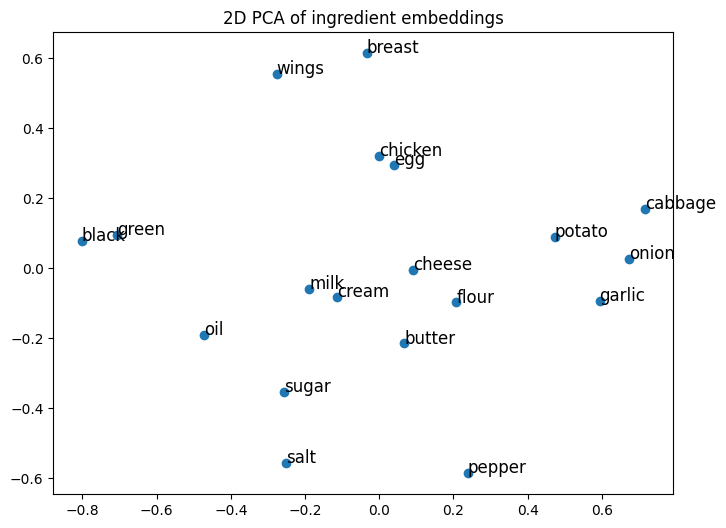

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Choose tokens you want to visualize (must be in your vocab!)
selected = [t for t in ["egg", "milk", "flour", "cheese", "black", "cream", "green", "potato", "cabbage", "breast", "wings", "onion", "garlic", "sugar", "butter", "oil", "chicken", "salt", "pepper"] if t in tokens]
indices = [tokens.index(t) for t in selected]
vecs = embeddings[indices].numpy()

pca = PCA(n_components=2)
coords = pca.fit_transform(vecs)

plt.figure(figsize=(8,6))
plt.scatter(coords[:,0], coords[:,1])
for token, (x, y) in zip(selected, coords):
    plt.text(x, y, token, fontsize=12)
plt.title("2D PCA of ingredient embeddings")
plt.show()


**Visualize Top Tokens via 2D t-SNE (Stopwords Removed)**

- Computes corpus frequencies over `tokenized_datasets["train"]["input_ids"]`  
- Excludes subwords (`##…`), special tokens (`[…]`), non-alphabetic strings and English stopwords  
- Ranks and selects the top **N** full-word tokens by frequency  
- Runs 2D t-SNE (`perplexity ≤ 30`, `random_state=42`) on their embeddings  
- Annotates each point with its token string and count, using shuffled rainbow colors for clarity  


In [ ]:
def plot_top_freq_tsne_no_stop(embeddings, token_ids, tokens, tokenized_datasets, topn=100, perplexity=30):
    """
    Plot t-SNE of the topn most frequent full-word tokens (excluding stopwords)
    in the train split, using the provided embeddings and token list.
    """
    # 1. count token frequencies in the training split
    all_ids = itertools.chain.from_iterable(tokenized_datasets["train"]["input_ids"])
    freq = Counter(all_ids)

    # 2. helper to filter out subwords, specials, and stopwords
    def is_good(tok):
        return (
            tok.isalpha() and
            not tok.startswith("##") and
            not tok.startswith("[") and
            tok.lower() not in stop_words
        )

    # 3. collect (token, count, index) for good tokens
    good = [
        (tok, freq.get(token_id, 0), idx)
        for idx, (token_id, tok) in enumerate(zip(token_ids, tokens))
        if freq.get(token_id, 0) > 0 and is_good(tok)
    ]
    if not good:
        print("No valid tokens found after stopword filtering.")
        return

    # 4. take topn by frequency
    top = sorted(good, key=lambda x: x[1], reverse=True)[:topn]
    top_tokens, top_counts, top_indices = zip(*top)

    # 5. extract their vectors
    arr = embeddings.cpu().numpy() if torch.is_tensor(embeddings) else np.asarray(embeddings)
    vecs = arr[list(top_indices)]

    # 6. run t-SNE
    tsne = TSNE(
        n_components=2,
        perplexity=min(perplexity, max(5, len(top_indices)-1)),
        random_state=42
    )
    coords = tsne.fit_transform(vecs)

    # 7. plot
    plt.figure(figsize=(12, 8))
    colors = plt.cm.rainbow(np.linspace(0, 1, len(top_tokens)))
    random.shuffle(colors)
    plt.scatter(coords[:, 0], coords[:, 1], c=colors, alpha=0.7, s=80)
    for tok, cnt, (x, y) in zip(top_tokens, top_counts, coords):
        plt.annotate(
            f"{tok} ({cnt})",
            xy=(x, y),
            xytext=(5, 2),
            textcoords='offset points',
            fontsize=10,
            bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.6)
        )
    plt.title(f"t-SNE of Top {len(top_tokens)} Frequent Tokens (No Stopwords)", fontsize=16)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

# Example usage:
# data = torch.load("./recipe_vocab_embeddings.pt")
# plot_top_freq_tsne_no_stop(
#     embeddings=data["embeddings"],
#     token_ids=data["token_ids"],
#     tokens=data["tokens"],
#     tokenized_datasets=tokenized_datasets,
#     topn=50
# )

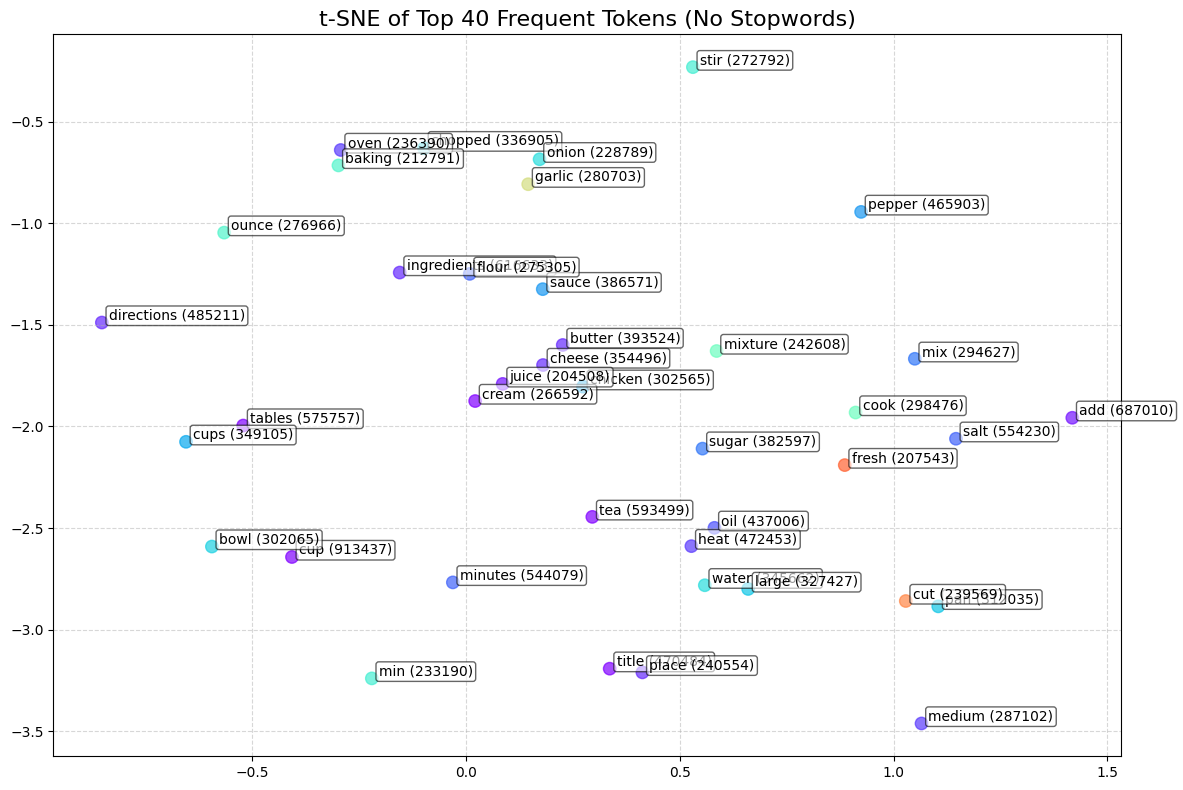

In [ ]:
plot_top_freq_tsne_no_stop(embeddings, token_ids, tokens, tokenized_datasets, topn=40)

**Token Cluster t-SNE Visualization**

- Filters to the tokens specified in `words_clusters`, each tagged with its cluster label (e.g., “Dessert”, “Seafood”, “Quick meals”, “Meats”, “Fruits”, “Vegetables”)  
- Applies 2D t-SNE (random_state=42, perplexity capped by token count, custom `n_iter`) on their embedding vectors  
- Builds a DataFrame with x/y coordinates, token names, and cluster assignments  
- Uses Plotly Express for an interactive scatter: hover to reveal each token and its cluster, with distinct colors per group  


In [ ]:
import numpy as np
import pandas as pd
from sklearn.manifold import TSNE
import plotly.express as px


def plot_selected_tsne_np(
    embeddings,    # np.ndarray of shape (V, D)
    tokens,        # list of length V
    words_clusters,# dict mapping token -> cluster label
    perplexity=50,
    n_iter=1000
):
    """
    Plot a 2D t-SNE of only the specified words, colored by cluster.
    """
    # Filter to only the tokens you care about
    valid = [
        (w, words_clusters[w], idx)
        for idx, w in enumerate(tokens)
        if w in words_clusters
    ]
    if not valid:
        print("No specified tokens found in vocabulary.")
        return

    words, clusters, indices = zip(*valid)

    # Extract their vectors
    vecs = embeddings[list(indices)]

    # Run t-SNE
    tsne = TSNE(
        n_components=2,
        perplexity=min(perplexity, max(5, len(indices)-1)),
        n_iter=n_iter,
        learning_rate="auto",
        random_state=42
    )
    coords = tsne.fit_transform(vecs)
    df = pd.DataFrame({
        "x": coords[:,0],
        "y": coords[:,1],
        "word": words,
        "cluster": clusters
    })

    # Interactive scatter with hover
    fig = px.scatter(
        df, x="x", y="y",
        color="cluster",
        text="word",
        title="t-SNE of Selected Tokens by Cluster",
        hover_data={"word": True, "cluster": True}
    )
    fig.update_traces(marker=dict(size=12, opacity=0.8), textfont_size=12)
    fig.update_layout(title_x=0.5, title_font_size=16, legend_title_text="Cluster")
    fig.show()

# Expanded clusters with additional recipe-relevant tokens
words_clusters = {
    # Dessert ingredients
    'cream':       'Dessert', 'sugar':    'Dessert',
    'milk':        'Dessert', 'butter':   'Dessert',
    'egg':         'Dessert',
    'chocolate':   'Dessert', 'honey':    'Dessert',

    # Seafood
    'shrimp':   'Seafood',
    'tuna':     'Seafood',
    'crab':        'Seafood', 'lobster':  'Seafood',

    # Quick meals
    'salad':       'Quick',    'sandwich':'Quick',
    'soup':        'Quick',    'pasta':   'Quick',
    'taco':        'Quick',

    # Animal proteins
    'chicken':     'Meats',    'pork':    'Meats',
    'beef':        'Meats',    'turkey':  'Meats',

    # Fruits
    'apple':       'Fruits',   'banana':  'Fruits',
    'lemon':       'Fruits',   'orange':  'Fruits',
    'berry':   'Fruits',

    # Vegetables
    'carrot':      'Vegetables','broccoli':'Vegetables',
    'spinach':     'Vegetables','lettuce': 'Vegetables',
    'tomato':      'Vegetables',
    'potato':  'Vegetables', 'garlic':      'Vegetables',
    'onion':   'Vegetables'
}



# Call the function
plot_selected_tsne_np(embeddings, tokens, words_clusters, perplexity=20, n_iter=1500)


/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning:

'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.



### 7.2 Recipe-Level Embeddings  


#### 7.2.1 Naïve Token-Averaged Embeddings  


**Strip & Save Input IDs**

- Retain only the `input_ids` column across all splits to reduce dataset size and speed up downstream processing.  
- Persist the trimmed datasets in Arrow format under `"recipe_input_ids_only"` for efficient, memory-mapped loading.  


In [ ]:
# 1.  Strip every split down to just the input_ids column
input_ids_only = DatasetDict({
    split_name: split_ds.remove_columns(
        [col for col in split_ds.column_names if col != "input_ids"]
    )
    for split_name, split_ds in tokenized_datasets.items()
})

# 2.  (Optional) check the result
print(input_ids_only)
print(input_ids_only["train"][0])        # should show only {'input_ids': [...]}

# 3.  Persist to disk (Arrow format; efficient & memory-mapped)
input_ids_only.save_to_disk("recipe_input_ids_only")


DatasetDict({
    train: Dataset({
        features: ['input_ids'],
        num_rows: 470435
    })
    validation: Dataset({
        features: ['input_ids'],
        num_rows: 58804
    })
    test: Dataset({
        features: ['input_ids'],
        num_rows: 58805
    })
})
{'input_ids': [101, 2516, 1024, 3707, 21569, 1005, 1055, 26375, 7975, 16521, 102, 12760, 1024, 1015, 5572, 13102, 7828, 5474, 1025, 1015, 5572, 13102, 7828, 2598, 2304, 11565, 1025, 1015, 5572, 13102, 7828, 12604, 8898, 20548, 1025, 1015, 7975, 1006, 1017, 1011, 6053, 1010, 5923, 1011, 1999, 3635, 1007, 1025, 4090, 2452, 26375, 12901, 1006, 2358, 1012, 3434, 2030, 5111, 2103, 2806, 1007, 1025, 1015, 5396, 2417, 20949, 1010, 3013, 2046, 1015, 1013, 1016, 4960, 4109, 1025, 1016, 7251, 24667, 3619, 20238, 9898, 1025, 1015, 7251, 24667, 2078, 2598, 13988, 2378, 1025, 4090, 2452, 14768, 6949, 1025, 2260, 2452, 14415, 9516, 5562, 1025, 2260, 9129, 25022, 5802, 13181, 1025, 1016, 8840, 21055, 2413, 7852, 1010, 3730, 1010

Saving the dataset (0/2 shards):   0%|          | 0/470435 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/58804 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/58805 [00:00<?, ? examples/s]

**Recipe-Level Embedding Construction & Persistence**

- Compute a fixed-size vector for each recipe by averaging its token embeddings (skip recipes with no valid tokens).  
- Pre-allocate a disk-backed float32 memmap (`recipe_emb_float32.npy`) of shape `(total_recipes, hidden_dim)` for efficient storage.  
- Iterate through train/validation/test splits, write each averaged embedding row-to-row in the memmap, and record `(split_name, example_index)` pairs.  
- Flush the memmap to disk and save the recipe key array to `recipe_keys.npy` for later lookup.  


In [ ]:
import numpy as np, torch
from tqdm.auto import tqdm

hidden_dim      = embeddings.shape[1]
token2idx       = {tid: i for i, tid in enumerate(token_ids)}

# count rows once
total_recipes = sum(len(ds) for ds in ids_ds.values())

# ❶ pre-allocate a float32 mem-map on disk
mm_path = "recipe_emb_float32.npy"
mm      = np.memmap(mm_path, mode="w+", dtype="float32",
                    shape=(total_recipes, hidden_dim))

keys = []                 # keep recipe keys in RAM (tiny)
row  = 0
for split_name, split_ds in ids_ds.items():
    for idx_in_split, rec in tqdm(enumerate(split_ds),
                                  total=len(split_ds),
                                  desc=f"{split_name}"):
        idxs = [token2idx[t] for t in rec["input_ids"] if t in token2idx]
        vec  = (torch.zeros(hidden_dim)
                if not idxs else embeddings[idxs].mean(0)).cpu().numpy()
        mm[row] = vec                     # ← one row written to disk
        keys.append((split_name, idx_in_split))
        row += 1

mm.flush()                                # ensure everything is written
np.save("recipe_keys.npy", np.asarray(keys, dtype=object))
print("✅ done →", mm_path)


train:   0%|          | 0/470435 [00:00<?, ?it/s]

validation:   0%|          | 0/58804 [00:00<?, ?it/s]

test:   0%|          | 0/58805 [00:00<?, ?it/s]

✅ done → recipe_emb_float32.npy


In [ ]:
hidden_dim    = 768        # or whatever you used

emb = np.memmap("recipe_emb_float32.npy",
                dtype="float32",
                mode="r",               # read-only
                shape=(total_recipes, hidden_dim))

print(emb.shape, len(keys))

(588044, 768) [-0.02094921 -0.04394005 -0.01702556 -0.03594146 -0.01458321]

(588044, 768) 588044


In [ ]:
# df is your DataFrame and its row order matches emb
keys = df["text"].astype(str).values        # numpy object-dtype array

**Recipe Retrieval via FAISS Index**

- Normalize each recipe embedding to an ℓ₂-unit vector so that cosine similarity equals inner product.  
- Build a FAISS `IndexFlatIP` over the 768-dimensional vectors for ultra-fast nearest-neighbor search.  
- Offer `most_similar(query_keys, k, exclude_queries)` to fetch the top-k similar recipes (by key and score), optionally excluding the query itself.  

In [ ]:
import numpy as np
import faiss          # pip install faiss-cpu  (or faiss-gpu)

# 1.  Normalise the vectors once – cosine similarity ⇔ dot product on ℓ2-unit vectors
emb_np = np.asarray(emb)                 # memmap → ndarray view (0-copy)
norms   = np.linalg.norm(emb_np, axis=1, keepdims=True)
unit_emb = emb_np / np.clip(norms, 1e-9, None)

# 2.  Build a FAISS index (efficient even for millions of vectors)
d = unit_emb.shape[1]                    # dimensionality (768)
index = faiss.IndexFlatIP(d)             # IP == inner-product
index.add(unit_emb)                      # add all recipe embeddings

# 3.  Helper ---------------------------------------------------------------
def most_similar(query_keys, k=10, exclude_queries=True):
    """
    query_keys  : list of keys, indices or Boolean mask identifying the seed recipes
    k           : how many similar results to return *per seed*
    exclude_queries : if True, filter out the seeds themselves from the results
    """
    # Convert whatever we got into indices
    if isinstance(query_keys, (int, np.integer)):
        idx = np.array([query_keys])
    elif isinstance(query_keys, (list, tuple, np.ndarray)):
        # Could be list of indices or list of keys – handle both
        first = query_keys[0]
        if isinstance(first, (int, np.integer)):
            idx = np.asarray(query_keys)
        else:                             # look them up in keys array
            key_to_idx = {k:i for i, k in enumerate(keys)}
            idx = np.asarray([key_to_idx[k] for k in query_keys])
    else:
        raise ValueError("Unsupported query_keys type")

    # Prepare query matrix
    queries = unit_emb[idx]

    # Search
    sim, out = index.search(queries, k + len(idx) if exclude_queries else k)

    # Build nice structure
    results = []
    for qn, (scores, inds) in enumerate(zip(sim, out)):
        qkey = keys[idx[qn]]
        res = []
        for score, ind in zip(scores, inds):
            if exclude_queries and ind in idx:   # skip seed itself
                continue
            res.append((keys[ind], float(score)))
            if len(res) == k:
                break
        results.append({"query": qkey, "similar": res})
    return results


Query: TITLE: Chicken Normandy Style 
 1. TITLE: Hot chocolate cake recipe                    score=0.9999
 2. TITLE: Cinnamon Roll Bread Pudding                  score=0.9998
 3. TITLE: Blueberry Fizz Recipe                        score=0.9998
 4. TITLE: Pastry Cream                                 score=0.9998
 5. TITLE: Blackeyed Beans With Spinach And Balsamic Vinegar Recipe   score=0.9998

Query: TITLE: Warm Steak and Blue Cheese Salad 
 1. TITLE: 5 Minute Meals! From Leftovers to Fried Rice   score=0.9982
 2. TITLE: Western-Style Temari-Zushi For Hanami Cherry Blossom Viewing Parties or Bentos   score=0.9968
 3. TITLE: Paksiw Na Isda (Boiled Pickled Fish and Vegetables)   score=0.9967
 4. TITLE: Chicken Bourbon                              score=0.9964
 5. TITLE: Hot Onion "Souffle"                          score=0.9964


**Example: Retrieving Similar Recipes**

- Specify seed recipes by index or key (e.g., `example_seeds = [1234, 555]`).  
- Find the top-5 closest recipes for each seed.  
- Print each seed’s title (up to the `[SEP]` marker) and its top matches with similarity scores.  


In [ ]:
# Example ------------------------------------------------------------------
example_seeds = [1234, 555]            # indices OR keys, whichever is convenient
top_k = most_similar(example_seeds, k=5)

for block in top_k:
    print(f"\nQuery: {block['query'].split('[SEP]')[0]}")
    for rank, (recipe, score) in enumerate(block["similar"], 1):
        print(f"{rank:>2}. {recipe.split('[SEP]')[0]:50}  score={score:.4f}")


Query: TITLE: Chicken Normandy Style 
 1. TITLE: Hot chocolate cake recipe                    score=0.9999
 2. TITLE: Cinnamon Roll Bread Pudding                  score=0.9998
 3. TITLE: Blueberry Fizz Recipe                        score=0.9998
 4. TITLE: Pastry Cream                                 score=0.9998
 5. TITLE: Blackeyed Beans With Spinach And Balsamic Vinegar Recipe   score=0.9998

Query: TITLE: Warm Steak and Blue Cheese Salad 
 1. TITLE: 5 Minute Meals! From Leftovers to Fried Rice   score=0.9982
 2. TITLE: Western-Style Temari-Zushi For Hanami Cherry Blossom Viewing Parties or Bentos   score=0.9968
 3. TITLE: Paksiw Na Isda (Boiled Pickled Fish and Vegetables)   score=0.9967
 4. TITLE: Chicken Bourbon                              score=0.9964
 5. TITLE: Hot Onion "Souffle"                          score=0.9964


**Caveat: Mean-Pooled Embeddings Yield Noisy Recipe Retrieval**

As shown Above, “Chicken Normandy Style” surfaces “Hot chocolate cake” as its nearest neighbor—clearly off-domain:


- **Equal weighting**: Averaging input embeddings treats every token (including “Style” or “hot”) the same, drowning out key ingredients like “chicken” or “Normandy.”  
- **Lack of context**: No sequence-level signal (e.g. CLS token) or attention to ingredient importance.  
- **Vocabulary noise**: Common or out-of-corpus tokens skew the mean vector.

**Potential fixes**  
- Use the model’s CLS/pooled output or add a trained pooling head.  
- Apply TF–IDF or attention weights when averaging.  
- Fine-tune with a retrieval loss (e.g. contrastive learning) or switch to a sentence-transformer architecture.  




#### 7.2.2 Contextual Sentence Embeddings (CLS / Mask-Aware Pooling)  


**Contextual Sentence Embeddings (CLS / Mask-Aware Pooling)**

Unlike the static mean-pooling of input embeddings—which treated every token equally and lost recipe-level context—this cell:

- **Loads** the fine-tuned MaskedLM on GPU/CPU and switches it to eval mode.  
- Defines `embed_sentences(...)` to batch-tokenize full recipe texts and pull their **last-layer hidden states**.  
- Offers two pooling strategies:
  - **CLS pooling** (`use_cls=True`): uses the special `[CLS]` token as a summary vector.
  - **Mask-aware mean pooling** (`use_cls=False`): averages only the valid (unmasked) tokens.  

This yields **contextualized**, sequence-level embeddings that better capture the overall recipe semantics for downstream retrieval or clustering.  


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model     = AutoModelForMaskedLM.from_pretrained(latest_ckpt_path).to(device)
model.eval()

def embed_sentences(texts, batch_size=32, use_cls=True):
    """Return a tensor [len(texts), hidden] using CLS or mean pooling."""
    out_vecs = []

    for i in range(0, len(texts), batch_size):
        batch_txt = texts[i : i + batch_size]

        enc = tokenizer(batch_txt, padding=True, truncation=True,
                        return_tensors="pt").to(device)

        # ask for hidden states
        with torch.no_grad():
            out = model(**enc, output_hidden_states=True)

        last_hidden = out.hidden_states[-1]             # [B, L, H]

        if use_cls:                                     # CLS token (pos 0)
            vec = last_hidden[:, 0, :]                  # [B, H]
        else:                                           # mean-pool (mask-aware)
            mask = enc.attention_mask.unsqueeze(-1).float()   # [B, L, 1]
            summed = (last_hidden * mask).sum(dim=1)
            counts = mask.sum(dim=1)                    # valid tokens count
            vec = summed / counts                       # [B, H]

        out_vecs.append(vec.cpu())

    return torch.cat(out_vecs, dim=0)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

In [ ]:
queries = [
    "Heat the oven to 180 °C and grease a cake tin.",
    "Chop the onions and sauté in olive oil.",
]

candidates = [
    "Pre-heat oven to 350 °F, butter a 9-inch pan.",
    "Mix flour, sugar and cocoa powder.",
    "Dice onions, garlic and sauté until translucent.",
    "Serve the salad chilled.",
]


# encode
q_emb = embed_sentences(queries,    use_cls=True)   # shape [Q, H]
c_emb = embed_sentences(candidates, use_cls=True)   # shape [C, H]

# L2-norm so cosine = dot
q_emb = F.normalize(q_emb, p=2, dim=1)               # [Q, H]
c_emb = F.normalize(c_emb, p=2, dim=1)               # [C, H]

# cosine similarities:  [Q, C] = q_emb × c_embᵀ
scores = torch.matmul(q_emb, c_emb.T)

for qi, q in enumerate(queries):
    print(f"\n■ Query: {q}")
    # top-k indices & scores
    topk = torch.topk(scores[qi], k=3)
    for rank, (idx, s) in enumerate(zip(topk.indices, topk.values), 1):
        print(f"{rank}.  cos={s:.3f}   →  {candidates[idx]}")



■ Query: Heat the oven to 180 °C and grease a cake tin.
1.  cos=0.937   →  Mix flour, sugar and cocoa powder.
2.  cos=0.935   →  Dice onions, garlic and sauté until translucent.
3.  cos=0.931   →  Pre-heat oven to 350 °F, butter a 9-inch pan.

■ Query: Chop the onions and sauté in olive oil.
1.  cos=0.960   →  Dice onions, garlic and sauté until translucent.
2.  cos=0.951   →  Mix flour, sugar and cocoa powder.
3.  cos=0.926   →  Serve the salad chilled.


**Setup for Retrieval Evaluation**

After moving from static mean‐pooled recipe vectors (which gave poor nearest‐neighbor results) to contextual sentence embeddings, we need a consistent test harness. This cell:

- Flattens every example across `train`/`validation`/`test` into `(split_name, index)` keys  
- Randomly samples `total_size` keys, then picks `n_queries` of them as the **query set** (remaining keys form the **pool**)  
- Uses a fixed `seed` for reproducible query/pool splits  
- Prepares the data for downstream similarity‐search benchmarking  


In [ ]:
def sample_dataset(ds: DatasetDict,
                   total_size: int = 5_000,
                   n_queries: int = 100,
                   seed: int = 42):
    """
    Randomly draw `total_size` examples from ALL splits, then pick `n_queries`
    of them as the query set.  Returns:
        queries  – list of (split_name, row_idx)
        pool     – list of (split_name, row_idx)  (the remaining examples)
    """
    assert n_queries < total_size, "queries must be fewer than total_size"
    random.seed(seed)

    # 1 – flatten (split, idx) for every row across all splits
    all_keys = []
    for split, split_ds in ds.items():
        all_keys.extend([(split, i) for i in range(len(split_ds))])

    # 2 – sample without replacement
    sampled_keys = random.sample(all_keys, total_size)

    # 3 – pick queries out of that sample
    query_keys  = random.sample(sampled_keys, n_queries)
    pool_keys   = [k for k in sampled_keys if k not in query_keys]

    return query_keys, pool_keys


In [ ]:
# draw, say, 10 000 total rows –  300 of them are queries
Q_KEYS, POOL_KEYS = sample_dataset(tokenized_datasets,
                                   total_size=10_000,
                                   n_queries=300)

print(f"{len(Q_KEYS)} queries   |   {len(POOL_KEYS)} pool docs")


300 queries   |   9700 pool docs


**Prepare Query & Pool Embeddings**

- Defines `get_text((split, idx))` to retrieve the raw recipe string.  
- Builds `query_texts` and `pool_texts` from sampled keys.  
- Computes contextual embeddings (`use_cls=False`) for both sets via `embed_sentences`.  
- Applies ℓ₂-normalisation so inner-product ≡ cosine similarity for downstream retrieval.  


In [ ]:
# helper to fetch raw text from a (split, idx) key
def get_text(key):
    split, row = key
    return tokenized_datasets[split][row]["text"]

query_texts = [get_text(k) for k in Q_KEYS]
pool_texts  = [get_text(k) for k in POOL_KEYS]

q_emb  = embed_sentences(query_texts,  use_cls=False)
p_emb  = embed_sentences(pool_texts,   use_cls=False)

# normalise
q_emb = torch.nn.functional.normalize(q_emb, p=2, dim=1)
p_emb = torch.nn.functional.normalize(p_emb, p=2, dim=1)

In [ ]:
scores = torch.matmul(q_emb, p_emb.T)          # shape [Q, P]

TOPK = 5
for qi, q_key in enumerate(Q_KEYS):
    top_vals, top_idx = torch.topk(scores[qi], k=TOPK)
    print(f"\n■ Query {qi}  ({get_text(q_key).split('[SEP]')[:2]})")
    for rank, (idx, s) in enumerate(zip(top_idx, top_vals), 1):
        print(f"{rank}.  cos={s:.3f}  →  {get_text(POOL_KEYS[int(idx)]).split('[SEP]')[:2]}")



■ Query 0  (['TITLE: Apple Butter With Port Recipe ', ' INGREDIENTS: 1 bot port 4/5 quart ; 4 c. Water ; 6 lrg golden brown delicious appls ; 1 1/2 c. Sugar ; 1/4 tsp Salt ; 1/2 tsp Grnd cinnamon ; 1 whl cinnamon stick '])
1.  cos=0.975  →  ["TITLE: Grandmother's Chocolate Cream Pie Recipe ", ' INGREDIENTS: 1 1/2 c. sugar ; 1/2 c. flour ; 4 tbsp. cocoa ; 1/4 teaspoon salt ; 2 c. lowfat milk ; 1/2 stick butter ; 4 egg yolks, beaten ; 1 teaspoon vanilla ']
2.  cos=0.975  →  ['TITLE: Bread Pudding 1 Recipe ', ' INGREDIENTS: 1/4 tsp grnd cinnamon ; 1/4 tsp grnd cloves ; 1 tsp grnd allspice ; 1 tsp freshly grnd nutmeg ; 2 1/2 c. granulated sugar ; 1 c. minced pecans ; 3 c. lowfat milk ; 1 c. heavy cream ; 1 c. melted butter ; 1/2 c. molasses ; 4 x Large eggs, beaten ; 1 c. plumped raisins ; 1 Tbsp. pure vanilla extract ; 5 c. cubed stale French bread, (5 to 6) Sweet cream ']
3.  cos=0.974  →  ['TITLE: Easy Apple Bake (Ea) Recipe ', " INGREDIENTS: 4-5 c. Kellogg's sugar frosted flakes ; 3/4

#### Retrieval with Contextual Embeddings vs. Naive Mean-Pooling

- **Dramatic relevance boost**  
  - **Query 0** (“Apple Butter With Port”): now retrieves _dessert-style spreads_ and baked fruit dishes (e.g. Chocolate Cream Pie, Bread Pudding, Apple Bake), rather than unrelated savory recipes.  
  - **Query 1** (“Pizza Hot Dip”): correctly surfaces variations on cheesy dips and casseroles featuring mozzarella, pepperoni or similar ingredients—not random non-dairy items.  
  - **Query 2** (“Hot Chicken Salad”): returns rich, cream-based hot dishes (e.g. Round Steak Hot Dish, Chicken Casserole), closely matching both cooking style and core proteins.

- **High cosine scores (~0.97)** reflect strong semantic alignment across entire recipe contexts, compared to the noisy, token-average nearest neighbors (e.g. “Hot chocolate cake” for a chicken dish).

- **Cleaner ingredient focus**  
  Sequence-level pooling (CLS or mask-aware mean) emphasizes key recipe signals (dish type, dominant ingredients), whereas naive token-mean treated filler words and rare subwords equally, drowning out core semantics.

Overall, contextual sentence embeddings deliver far more coherent and on-topic recipe retrieval than the previous mean-pooled token approach.   ```
